# Predictive maintenance project

This notebook focus on Data Wrangling and EDA of a synthetic database of machine failures, as shown in the url in the second cell of this notebook.

We will check for any inaccuracies in our data, and create some visualizations to provide some insights from our data, before diving into prediction models, in the other notebooks

in this first part, we will load the data

In [1]:
import pandas as pd
import zipfile
import numpy as np
import io
import os
import requests
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, make_scorer
)
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE,SVMSMOTE,RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import optuna
from sklearn.metrics import matthews_corrcoef, make_scorer
import shap
from sklearn.base import clone
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.multioutput import MultiOutputClassifier

C:\Users\danil\anaconda3\envs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
URL = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(URL, headers=headers)

In [172]:
zip_buffer = io.BytesIO(response.content)
with zipfile.ZipFile(zip_buffer) as z:     
    csv_files = z.namelist()
    print(f"Arquivos encontrados: {csv_files}")
    f = z.open(csv_files[0])
    print(f"Carregando: {f}...")
    df = pd.read_csv(f)

Arquivos encontrados: ['ai4i2020.csv']
Carregando: <zipfile.ZipExtFile name='ai4i2020.csv' mode='r'>...


In [173]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset analysis

As our data is loaded, let's check its shape, if there are no empty values and other characteristics

In [174]:
print(f"dataframe shape:{df.shape}\n")
print(df.info())

dataframe shape:(10000, 14)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: fl

As shown, our data does not seem to have any missing values.

Let's check our target features, how much ow our target variables are a true and negative, to see how unbalanced our data is.

In [201]:
print(f"Total Machine failures: {df['Machine failure'].sum()}, {df['Machine failure'].sum()/df['Machine failure'].count():.2%} of the dataset\n")
print(f"Total PWF: {df['PWF'].sum()}, {df['PWF'].sum()/df['PWF'].count():.2%} of the dataset")
print(f"Total HDF: {df['HDF'].sum()}, {df['HDF'].sum()/df['HDF'].count():.2%} of the dataset")
print(f"Total OSF: {df['OSF'].sum()}, {df['OSF'].sum()/df['OSF'].count():.2%} of the dataset")
print(f"Total TWF: {df['TWF'].sum()}, {df['TWF'].sum()/df['TWF'].count():.2%} of the dataset")
print(f"Total RNF: {df['RNF'].sum()}, {df['RNF'].sum()/df['RNF'].count():.2%} of the dataset")

Total Machine failures: 339, 3.39% of the dataset

Total PWF: 95, 0.95% of the dataset
Total HDF: 115, 1.15% of the dataset
Total OSF: 98, 0.98% of the dataset
Total TWF: 46, 0.46% of the dataset
Total RNF: 19, 0.19% of the dataset


### Remarks:

It is clear that our dataset is highly unbalanced, and we will for sure need some pre-processing of our data in our prediction models to have a good prediction performance.

Now, let's make a quick boxplot, to map our outliers along our continuous and integer features:

In [175]:
X = df.drop(columns = ['UDI','Product ID','TWF','Machine failure','HDF','PWF','OSF','RNF']).select_dtypes(include='number')
list(X.columns)

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

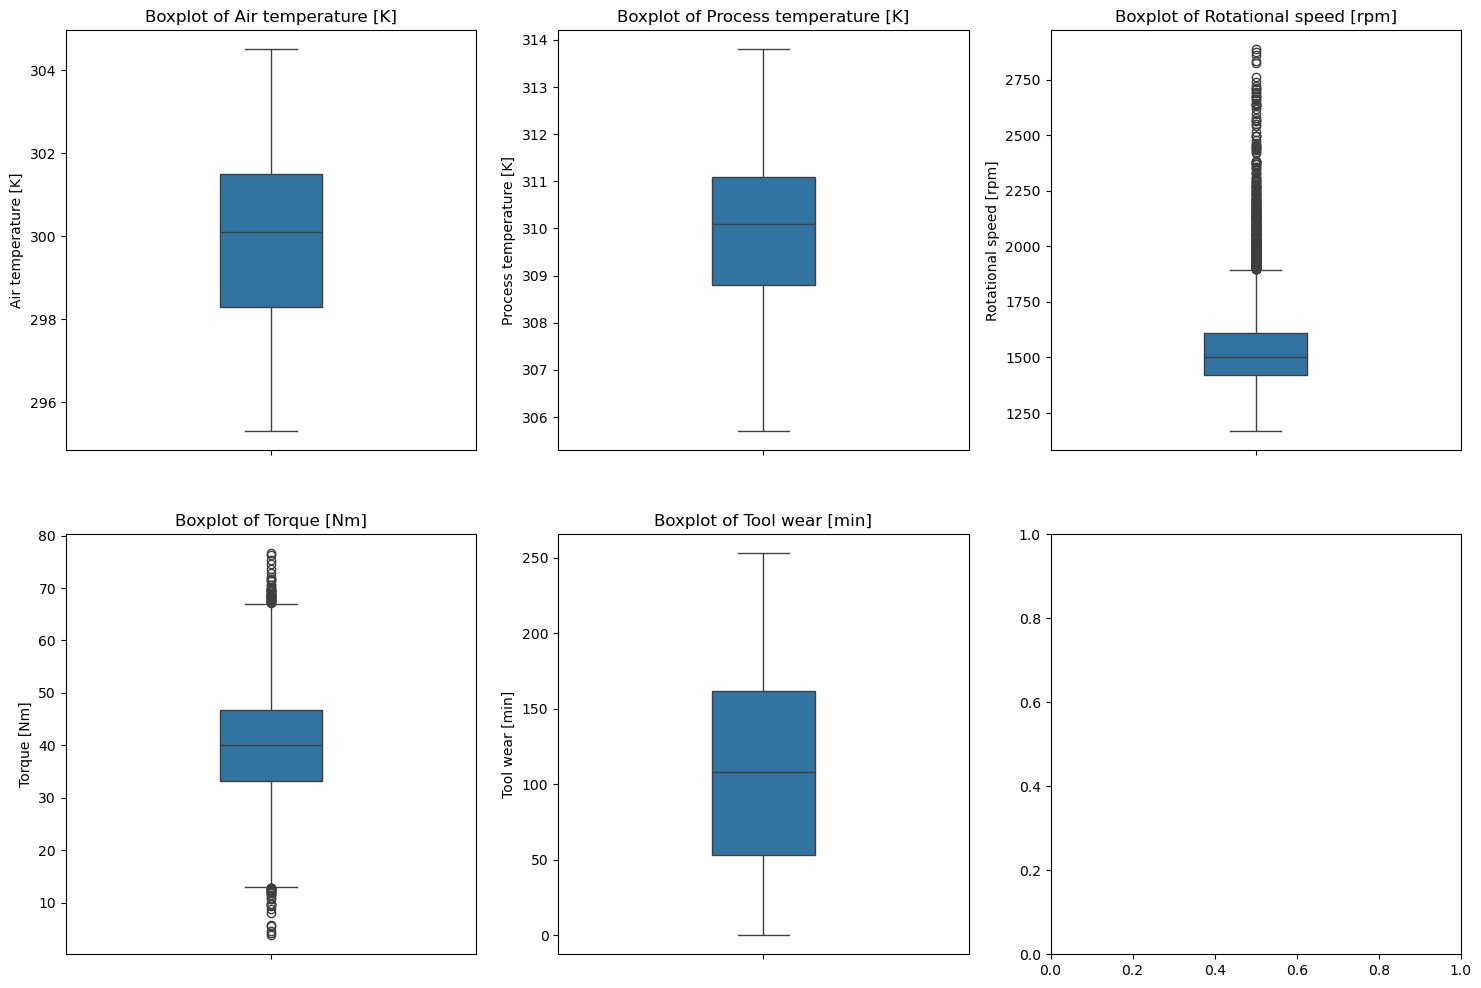

In [182]:
fig, ax = plt.subplots(2,3,figsize = (18,12))

for i,feature in enumerate(list(X.columns)):
    if i < 3:
        sns.boxplot(data = X, y = X[feature], ax = ax[0][i], width = 0.25)
        ax[0][i].set_title(f'Boxplot of {feature}')
    else:
        sns.boxplot(data = X, y = X[feature], ax = ax[1][i-3],width = 0.25)
        ax[1][i-3].set_title(f'Boxplot of {feature}')

### Boxplot Analysis

So, two features seems to have a high amount of outliers, that can be probably cause of failures or not. Let's separate the 2 plots with outliers to see if they are related to machine failures:

Text(0.5, 1.0, 'Boxplot of Rotational speed, with classes separation')

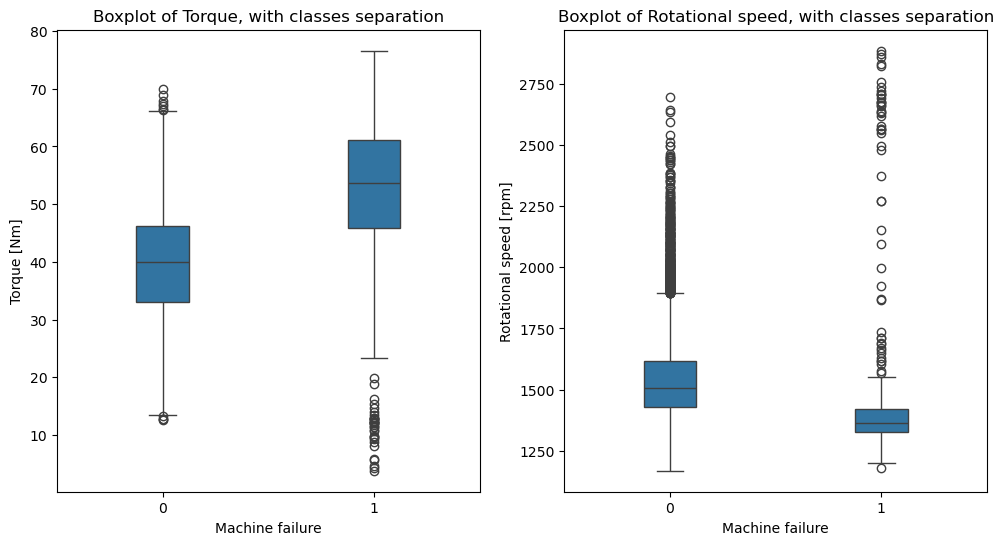

In [194]:
fig, ax = plt.subplots(1,2,figsize = (12,6))

sns.boxplot(data = df, y = 'Torque [Nm]', x = 'Machine failure', ax = ax[0], width = 0.25)
ax[0].set_title('Boxplot of Torque, with classes separation')
sns.boxplot(data = df, y = 'Rotational speed [rpm]', x = 'Machine failure', ax = ax[1],width = 0.25)
ax[1].set_title('Boxplot of Rotational speed, with classes separation')

Many outliers can be seen in the boxplots from both machines failing or not. But it is not still wise to remove them from our analysis, without checking our predictor's performance in later notebooks.

Now let's check our features correlations:

In [17]:
df.drop(columns = ['UDI','Product ID','TWF','Machine failure','HDF','PWF','OSF','RNF']).select_dtypes(include='number').corr()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000


Text(0.5, 1.0, 'Scatterplot of Process vs Air temperature')

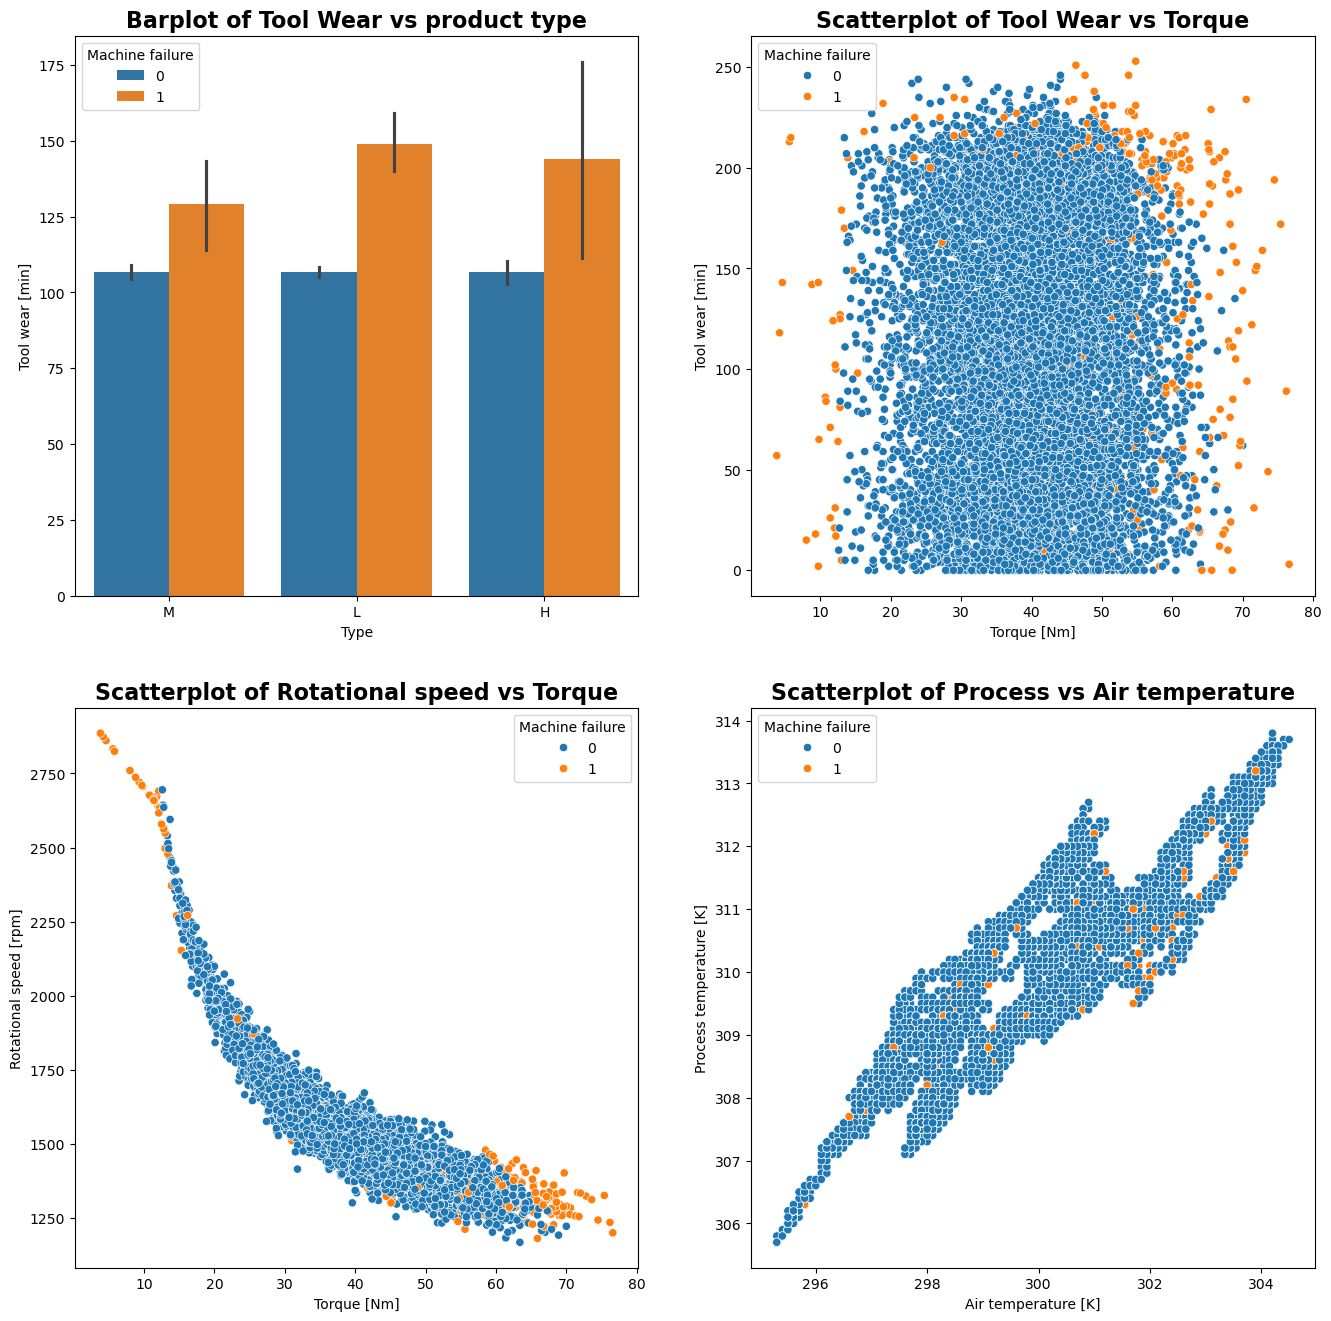

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(16,16))


sns.barplot(data = df, x='Type', y = 'Tool wear [min]', hue = 'Machine failure',ax=ax[0][0])
sns.scatterplot(data = df, x='Torque [Nm]', y = 'Tool wear [min]', hue = 'Machine failure',ax=ax[0][1])
sns.scatterplot(data = df, x='Torque [Nm]', y = 'Rotational speed [rpm]', hue = 'Machine failure',ax=ax[1][0])
sns.scatterplot(data = df, x='Air temperature [K]', y = 'Process temperature [K]', hue = 'Machine failure',ax=ax[1][1])

ax[0][0].set_title('Barplot of Tool Wear vs product type', fontweight = 'bold', fontsize = 16)
ax[0][1].set_title('Scatterplot of Tool Wear vs Torque', fontweight = 'bold', fontsize = 16)
ax[1][0].set_title('Scatterplot of Rotational speed vs Torque', fontweight = 'bold', fontsize = 16)
ax[1][1].set_title('Scatterplot of Process vs Air temperature', fontweight = 'bold', fontsize = 16)



From Our first 4 plots, we can confirm what was seen in the correlation matrix, as Process and air temperature shows a pattern of a linear positive correlation, while Rotational speed and torque have a negative correlation, but it does not seem to be that linear.

Also, from both the scatter of tool wear and rotational speed vs torque, shows a tendency of machine failures on both low and high torque characteristics.

To further analyze our problem, let's see the same graphs, but highlighting only the target failures related failures among these features, that will me shown in the legend label:

C:\Users\danil\AppData\Local\Temp\ipykernel_10840\342496500.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


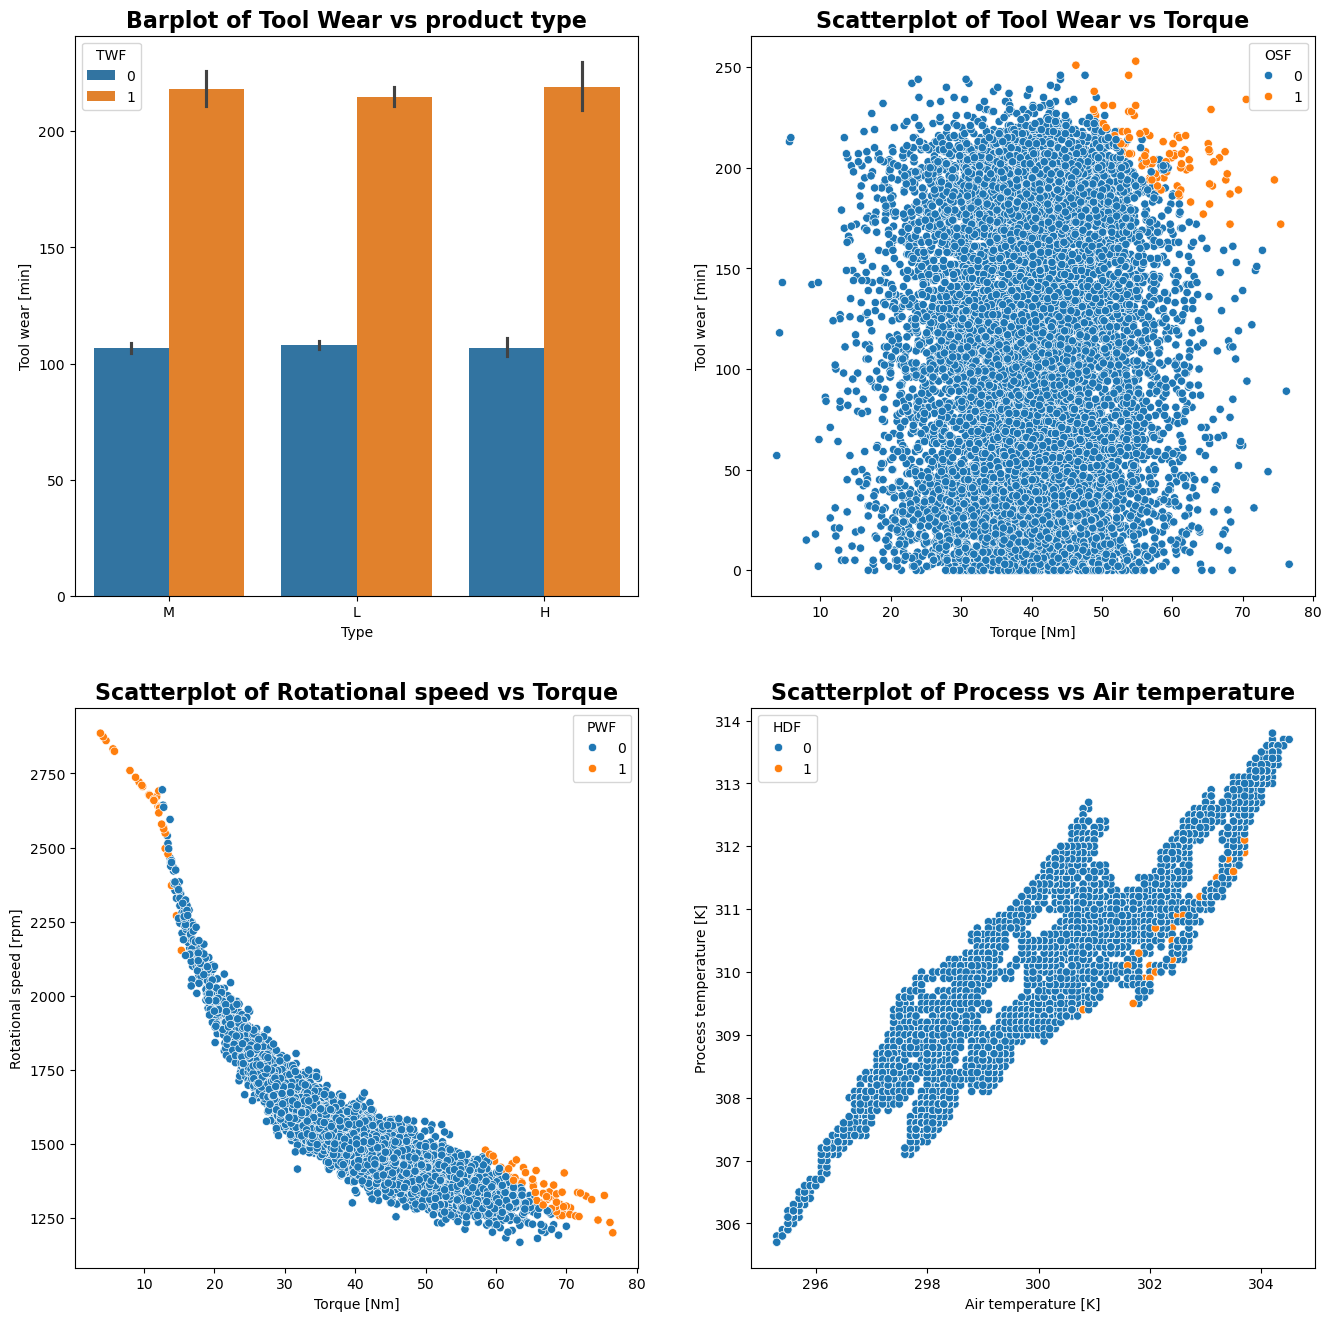

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(16,16))

sns.barplot(data = df, x='Type', y = 'Tool wear [min]', hue = 'TWF',ax=ax[0][0])
sns.scatterplot(data = df, x='Torque [Nm]', y = 'Tool wear [min]', hue = 'OSF',ax=ax[0][1])
sns.scatterplot(data = df, x='Torque [Nm]', y = 'Rotational speed [rpm]', hue = 'PWF',ax=ax[1][0])
sns.scatterplot(data = df, x='Air temperature [K]', y = 'Process temperature [K]', hue = 'HDF',ax=ax[1][1])

ax[0][0].set_title('Barplot of Tool Wear vs product type', fontweight = 'bold', fontsize = 16)
ax[0][1].set_title('Scatterplot of Tool Wear vs Torque', fontweight = 'bold', fontsize = 16)
ax[1][0].set_title('Scatterplot of Rotational speed vs Torque', fontweight = 'bold', fontsize = 16)
ax[1][1].set_title('Scatterplot of Process vs Air temperature', fontweight = 'bold', fontsize = 16)

fig.show()

The graphs shows some pattern regarding their probable main cause of failure: TWF exhibits a high mean value of time of use of the tool before failing, OSF shows high levels of torque and tool wear before failing, Rotational speed and torque shows failure patterns in their extremes, and process vs air temperature shows some failures whenever air temperatures are high, and process temperatures are at medium levels.

Now, let's try to combine all 5 modes of failure into single graphs, to check if more patterns can be seen in the data:

In [84]:
df_new = df.copy()

for coluna in list(df_new.columns)[9:]:
    df_new[coluna] = df_new[coluna].replace(1,coluna)
    df_new[coluna] = df_new[coluna].replace(0,"")

df_new[df_new['HDF']=='HDF'].head()

df_new['Failure mode'] = df_new['HDF']+df_new['OSF']+df_new['PWF']+df_new['TWF']+df_new['RNF']
#df_new['Failure mode'] = df_new['Failure mode'].str[:3]
df_new['Failure mode'] = df_new['Failure mode'].replace("",'No Failure')


In [85]:
df_new['Failure mode'].value_counts()

Failure mode
No Failure    9652
HDF            106
PWF             80
OSF             78
TWF             42
RNF             18
OSFPWF          12
HDFOSF           6
HDFPWF           3
OSFTWF           2
TWFRNF           1
Name: count, dtype: int64

When we compare the sum of our failure modes and after we created a new df, we see that these values changes. Since we combined all the columns and took only the first 3 letters of each, it means that we have more than 1 failure ocurring at once. Let's check how many times this happens:

In [66]:
multiple_failures = df['HDF']+df['OSF']+df['PWF']+df['TWF']+df['RNF']

In [68]:
multiple_failures.value_counts()

0    9652
1     324
2      23
3       1
Name: count, dtype: int64

So we have 324 times where just one failure ocurred, 23 times where 2 occurred, and 1 time only where 3 occurred. Let's not consider the 3-wya failure, and build a matrix to see if any pattern emerges from the comparison of a 2-way failure.

But first, let's check what is our 3-way failure. if it has a RNF in it, we will not consider the RNF, to easien the matrix build.

In [74]:
df.iloc[df.index[df[['HDF','OSF','PWF','TWF','RNF']].sum(axis = 1) == 3].to_list()]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
5909,5910,H35323,H,300.7,310.2,1364,65.3,208,1,1,0,1,1,0


Since we have both TWF and OSF, we will consider only PWF and OSF in this case, as TWF and OSF are related to high levels of tool wear, as seen in the scatterplots above.

In [83]:
df.loc[5909,'TWF'] = 0
df.loc[5909]

UDI                          5910
Product ID                 H35323
Type                            H
Air temperature [K]         300.7
Process temperature [K]     310.2
Rotational speed [rpm]       1364
Torque [Nm]                  65.3
Tool wear [min]               208
Machine failure                 1
TWF                             0
HDF                             0
PWF                             1
OSF                             1
RNF                             0
Name: 5909, dtype: object

In [ ]:
df['Failure mode'] = df_new['Failure mode'].copy()



## Failure mode analysis

In the next charts, we will be analysing how our failure modes behaves with the data provided, to gain some insights and detect some patterns.
We will Analyze PWF, followed by TWF and OSF, an then by HDF. RNF, as the name itself says, are random, so no pattern is expected to be seen, however they are also coing to be plotted.


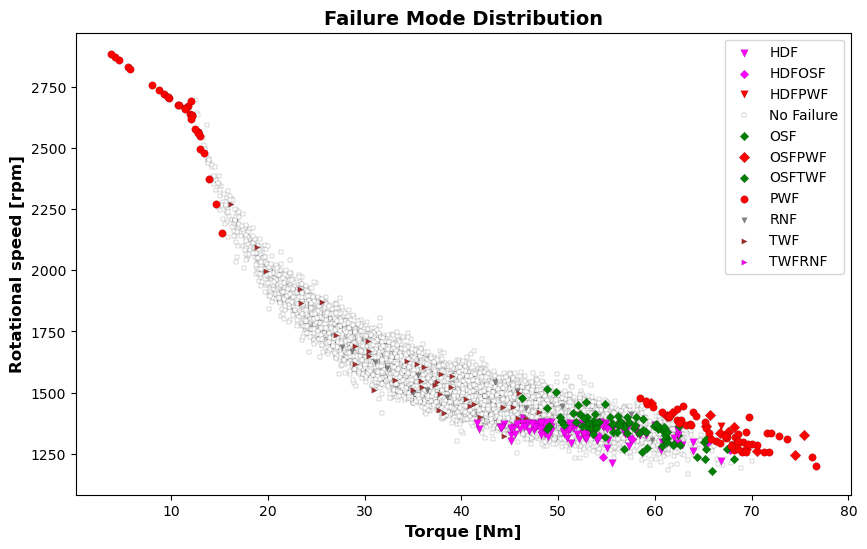

In [139]:
fig,ax = plt.subplots(1,1,figsize = (10,6))

marker = { 'HDF':'v',
            'HDFPWF':'o',
            'HDFOSF':'o',
            'OSF':'v',
            'OSFPWF':'o',
            'OSFTWF':'v',
            'PWF':'o',
            'RNF':'v',
            'TWF':'v',
            'TWFRNF':'v',
            'No Failure':'s'
          }

zorder_map   = { 'HDF':3,
            'HDFPWF':5,
            'HDFOSF':3,
            'OSF':4,
            'OSFPWF':5,
            'OSFTWF':2,
            'PWF':5,
            'RNF':2,
            'TWF':2,
            'TWFRNF':2,
            'No Failure':1
          }

size_map = { 'HDF':30,
            'HDFPWF':30,
            'HDFOSF':20,
            'OSF':20,
            'OSFPWF':30,
            'OSFTWF':20,
            'PWF':30,
            'RNF':15,
            'TWF':15,
            'TWFRNF':15,
            'No Failure':8
          }

palette = { 'HDF':'magenta',
            'HDFPWF':'red',
            'HDFOSF':'magenta',
            'OSF':'green',
            'OSFPWF':'red',
            'OSFTWF':'green',
            'PWF':'red',
            'RNF':'gray',
            'TWF':'brown',
            'TWFRNF':'magenta',
            'No Failure':'white'
          }


for classe, grupo in df.groupby('Failure mode'):
    ax.scatter(grupo['Torque [Nm]'], grupo['Rotational speed [rpm]'],
               s=size_map.get(classe, 30),
               label=classe,
               c = palette[classe],
               zorder = zorder_map[classe],
               edgecolors = 'black',
               marker = marker[classe],
               linewidths=0.1)
ax.set_xlabel('Torque [Nm]', fontsize=12, fontweight='bold')
ax.set_ylabel('Rotational speed [rpm]', fontsize=12, fontweight='bold')
ax.set_title('Failure Mode Distribution', fontsize=14, fontweight='bold')
ax.legend(title='Failure Mode', fontsize=10, title_fontsize=11)

plt.legend()

Now with better graphs control, it is clearer that all PWF related failures, are on the 'edges' of the scatterplot, showing that probably when machinery power levels reaches borderline values, the machine fails. It is a good indicative to inspect our predictive models later on

Also, HDF and OSF are related to high torque - low rotational speeds regime, while TWF seems to be sparse through this graph

Now let's check other features and their related features:

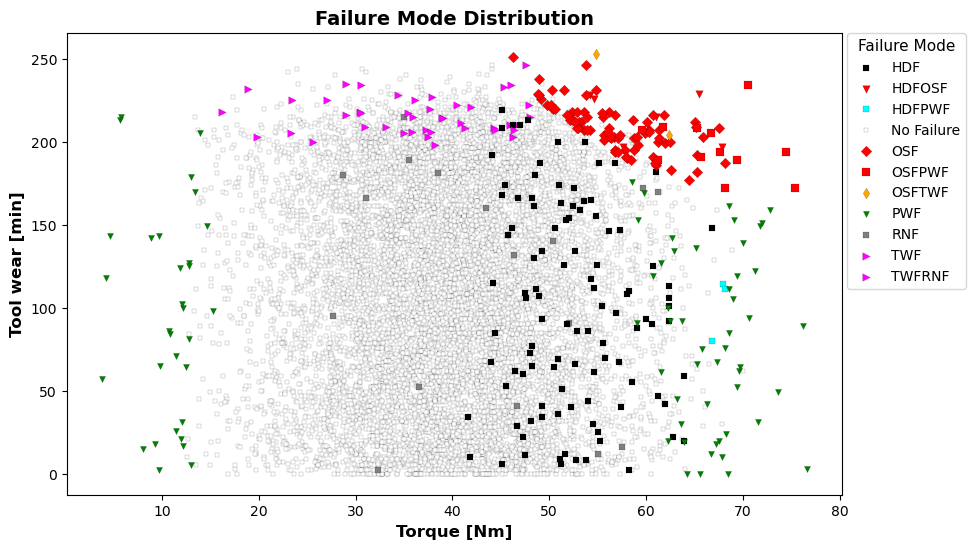

In [146]:
fig,ax = plt.subplots(1,1,figsize = (10,6))

marker = { 'HDF':'s',
            'HDFPWF':'s',
            'HDFOSF':'v',
            'OSF':'D',
            'OSFPWF':'s',
            'OSFTWF':'d',
            'PWF':'v',
            'RNF':'s',
            'TWF':'>',
            'TWFRNF':'>',
            'No Failure':'s'
          }

zorder_map   = { 'HDF':3,
            'HDFPWF':3,
            'HDFOSF':5,
            'OSF':5,
            'OSFPWF':5,
            'OSFTWF':5,
            'PWF':3,
            'RNF':2,
            'TWF':2,
            'TWFRNF':4,
            'No Failure':1
          }

size_map = { 'HDF':20,
            'HDFPWF':20,
            'HDFOSF':30,
            'OSF':30,
            'OSFPWF':30,
            'OSFTWF':30,
            'PWF':20,
            'RNF':15,
            'TWF':30,
            'TWFRNF':30,
            'No Failure':8
          }

palette = { 'HDF':'black',
            'HDFPWF':'cyan',
            'HDFOSF':'red',
            'OSF':'red',
            'OSFPWF':'red',
            'OSFTWF':'orange',
            'PWF':'green',
            'RNF':'gray',
            'TWF':'magenta',
            'TWFRNF':'magenta',
            'No Failure':'white'
          }


for classe, grupo in df.groupby('Failure mode'):
    ax.scatter(grupo[d:='Torque [Nm]'], grupo[f:='Tool wear [min]'],
               s=size_map.get(classe, 30),
               label=classe,
               c = palette[classe],
               zorder = zorder_map[classe],
               edgecolors = 'black',
               marker = marker[classe],
               linewidths=0.1)
ax.set_xlabel(d, fontsize=12, fontweight='bold')
ax.set_ylabel(f, fontsize=12, fontweight='bold')
ax.set_title('Failure Mode Distribution', fontsize=14, fontweight='bold')
ax.legend(title='Failure Mode', fontsize=10, title_fontsize=11,          
          bbox_to_anchor=(1.16, 1),
          loc='upper right',
          borderaxespad=0)

By this graph, it is clear that with increasing tool wear minutes, both OSF and TWF starts to appear. However, OSF have a more characteristic pattern, as they group themselves at high torque - high tool wear values, indicating that maybe the product of these two variables are the key factor to Overstrain failure.

TWF on the other hand, shows a distributed range among torque values, but starts appearing at about 200 min of tool wear. But it is not so clear if the high amount of minutes of tool wear is the factor contributing to TWF alone, as it can be seen that a lot of no failures comes togheter at the same range of values as TWF happens. This target might be troublesome for our model to predict with this feature alone.

There are also some PWF related failures on lower and higher levels of torque, but as seen in the graph before, it is related to torque x rotational speed, so it is expected that this pattern would be seen here.

Now let's check some temperature relations with HDF

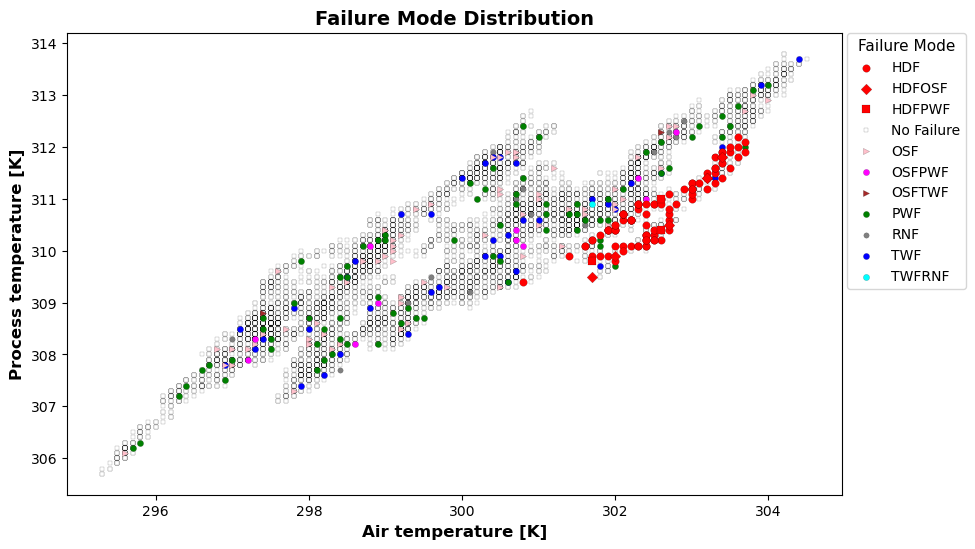

In [147]:
fig,ax = plt.subplots(1,1,figsize = (10,6))

marker = { 'HDF':'o',
            'HDFPWF':'s',
            'HDFOSF':'D',
            'OSF':'>',
            'OSFPWF':'o',
            'OSFTWF':'>',
            'PWF':'o',
            'RNF':'o',
            'TWF':'o',
            'TWFRNF':'o',
            'No Failure':'s'
          }

zorder_map   = { 'HDF':5,
            'HDFPWF':5,
            'HDFOSF':5,
            'OSF':3,
            'OSFPWF':3,
            'OSFTWF':3,
            'PWF':4,
            'RNF':2,
            'TWF':2,
            'TWFRNF':2,
            'No Failure':1
          }

size_map = { 'HDF':30,
            'HDFPWF':30,
            'HDFOSF':30,
            'OSF':20,
            'OSFPWF':20,
            'OSFTWF':20,
            'PWF':20,
            'RNF':15,
            'TWF':20,
            'TWFRNF':20,
            'No Failure':8
          }

palette = { 'HDF':'red',
            'HDFPWF':'red',
            'HDFOSF':'red',
            'OSF':'pink',
            'OSFPWF':'magenta',
            'OSFTWF':'brown',
            'PWF':'green',
            'RNF':'gray',
            'TWF':'blue',
            'TWFRNF':'cyan',
            'No Failure':'white'
          }


for classe, grupo in df.groupby('Failure mode'):
    ax.scatter(grupo[d:='Air temperature [K]'], grupo[f:='Process temperature [K]'],
               s=size_map.get(classe, 30),
               label=classe,
               c = palette[classe],
               zorder = zorder_map[classe],
               edgecolors = 'black',
               marker = marker[classe],
               linewidths=0.1)
ax.set_xlabel(d, fontsize=12, fontweight='bold')
ax.set_ylabel(f, fontsize=12, fontweight='bold')
ax.set_title('Failure Mode Distribution', fontsize=14, fontweight='bold')
ax.legend(title='Failure Mode', fontsize=10, title_fontsize=11,          
          bbox_to_anchor=(1.16, 1),
          loc='upper right',
          borderaxespad=0)

HDF also seems to be quite concentrated into a specific area, where the temeprature difference between air and process temperature ranges from 6 to 8 K, above 301 K for air temperature and 309 K for Process temperature.

The other modes of failure seems to be well sparsed in this scatterplot, so no other pattern can be seen.

Let's see if Tool Wear and rotational speed relates somehow, and check if the product type is influential in any way.

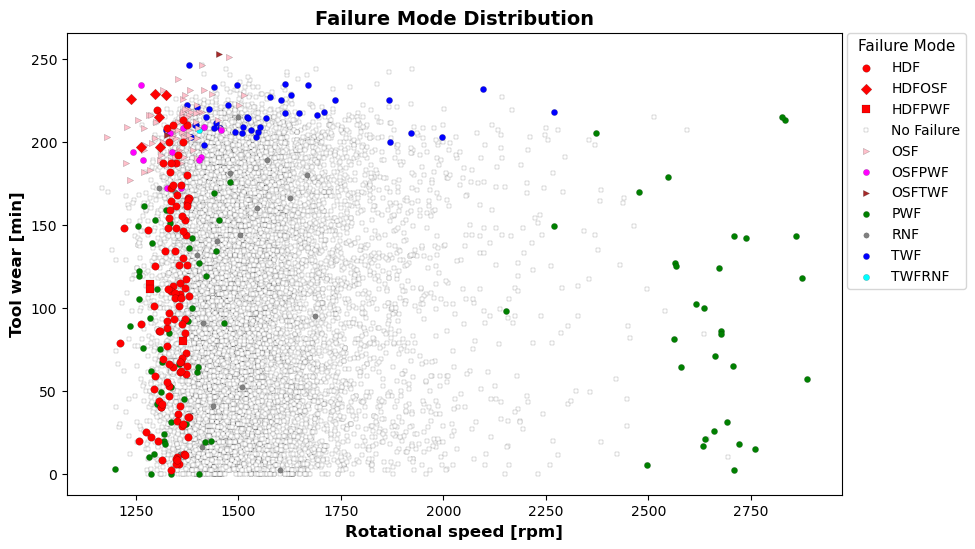

In [148]:
fig,ax = plt.subplots(1,1,figsize = (10,6))

marker = { 'HDF':'o',
            'HDFPWF':'s',
            'HDFOSF':'D',
            'OSF':'>',
            'OSFPWF':'o',
            'OSFTWF':'>',
            'PWF':'o',
            'RNF':'o',
            'TWF':'o',
            'TWFRNF':'o',
            'No Failure':'s'
          }

zorder_map   = { 'HDF':5,
            'HDFPWF':5,
            'HDFOSF':5,
            'OSF':3,
            'OSFPWF':3,
            'OSFTWF':3,
            'PWF':4,
            'RNF':2,
            'TWF':2,
            'TWFRNF':2,
            'No Failure':1
          }

size_map = { 'HDF':30,
            'HDFPWF':30,
            'HDFOSF':30,
            'OSF':20,
            'OSFPWF':20,
            'OSFTWF':20,
            'PWF':20,
            'RNF':15,
            'TWF':20,
            'TWFRNF':20,
            'No Failure':8
          }

palette = { 'HDF':'red',
            'HDFPWF':'red',
            'HDFOSF':'red',
            'OSF':'pink',
            'OSFPWF':'magenta',
            'OSFTWF':'brown',
            'PWF':'green',
            'RNF':'gray',
            'TWF':'blue',
            'TWFRNF':'cyan',
            'No Failure':'white'
          }


for classe, grupo in df.groupby('Failure mode'):
    ax.scatter(grupo[d:='Rotational speed [rpm]'], grupo[f:='Tool wear [min]'],
               s=size_map.get(classe, 30),
               label=classe,
               c = palette[classe],
               zorder = zorder_map[classe],
               edgecolors = 'black',
               marker = marker[classe],
               linewidths=0.1)
ax.set_xlabel(d, fontsize=12, fontweight='bold')
ax.set_ylabel(f, fontsize=12, fontweight='bold')
ax.set_title('Failure Mode Distribution', fontsize=14, fontweight='bold')
ax.legend(title='Failure Mode', fontsize=10, title_fontsize=11,          
          bbox_to_anchor=(1.16, 1),
          loc='upper right',
          borderaxespad=0)

So, HDF Failures, as expected, happening at Low RPM regimes.

let's try a different plot, and check how HDF failures behaves when plotting with RPM vs temperature diference between air and process

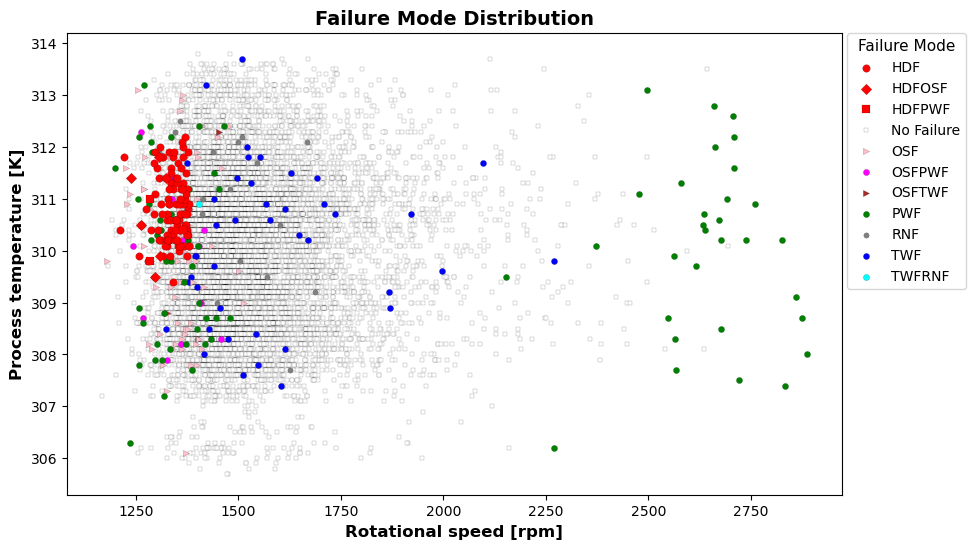

In [153]:

fig,ax = plt.subplots(1,1,figsize = (10,6))

marker = { 'HDF':'o',
            'HDFPWF':'s',
            'HDFOSF':'D',
            'OSF':'>',
            'OSFPWF':'o',
            'OSFTWF':'>',
            'PWF':'o',
            'RNF':'o',
            'TWF':'o',
            'TWFRNF':'o',
            'No Failure':'s'
          }

zorder_map   = { 'HDF':5,
            'HDFPWF':5,
            'HDFOSF':5,
            'OSF':3,
            'OSFPWF':3,
            'OSFTWF':3,
            'PWF':4,
            'RNF':2,
            'TWF':2,
            'TWFRNF':2,
            'No Failure':1
          }

size_map = { 'HDF':30,
            'HDFPWF':30,
            'HDFOSF':30,
            'OSF':20,
            'OSFPWF':20,
            'OSFTWF':20,
            'PWF':20,
            'RNF':15,
            'TWF':20,
            'TWFRNF':20,
            'No Failure':8
          }

palette = { 'HDF':'red',
            'HDFPWF':'red',
            'HDFOSF':'red',
            'OSF':'pink',
            'OSFPWF':'magenta',
            'OSFTWF':'brown',
            'PWF':'green',
            'RNF':'gray',
            'TWF':'blue',
            'TWFRNF':'cyan',
            'No Failure':'white'
          }


for classe, grupo in df.groupby('Failure mode'):
    ax.scatter(grupo[d:='Rotational speed [rpm]'], grupo[f:='Process temperature [K]'],
               s=size_map.get(classe, 30),
               label=classe,
               c = palette[classe],
               zorder = zorder_map[classe],
               edgecolors = 'black',
               marker = marker[classe],
               linewidths=0.1)
ax.set_xlabel(d, fontsize=12, fontweight='bold')
ax.set_ylabel(f, fontsize=12, fontweight='bold')
ax.set_title('Failure Mode Distribution', fontsize=14, fontweight='bold')
ax.legend(title='Failure Mode', fontsize=10, title_fontsize=11,          
          bbox_to_anchor=(1.16, 1),
          loc='upper right',
          borderaxespad=0)

Not much could be infered here, as we already knew that at that range of rotational speed and Process temperature, HDF failures were concentrated. Let's try another view, by comparing the temperature diference between process and air temperature:

In [151]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

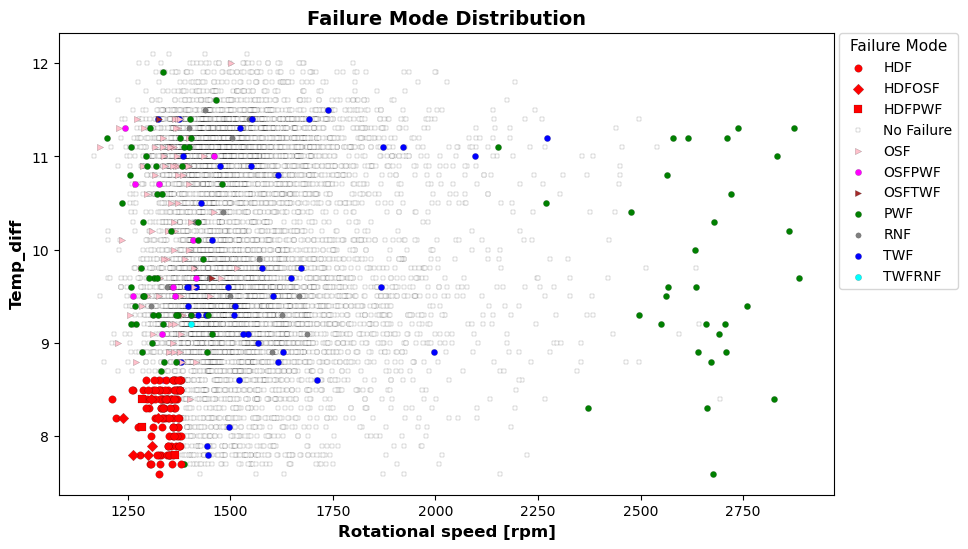

In [152]:

fig,ax = plt.subplots(1,1,figsize = (10,6))

marker = { 'HDF':'o',
            'HDFPWF':'s',
            'HDFOSF':'D',
            'OSF':'>',
            'OSFPWF':'o',
            'OSFTWF':'>',
            'PWF':'o',
            'RNF':'o',
            'TWF':'o',
            'TWFRNF':'o',
            'No Failure':'s'
          }

zorder_map   = { 'HDF':5,
            'HDFPWF':5,
            'HDFOSF':5,
            'OSF':3,
            'OSFPWF':3,
            'OSFTWF':3,
            'PWF':4,
            'RNF':2,
            'TWF':2,
            'TWFRNF':2,
            'No Failure':1
          }

size_map = { 'HDF':30,
            'HDFPWF':30,
            'HDFOSF':30,
            'OSF':20,
            'OSFPWF':20,
            'OSFTWF':20,
            'PWF':20,
            'RNF':15,
            'TWF':20,
            'TWFRNF':20,
            'No Failure':8
          }

palette = { 'HDF':'red',
            'HDFPWF':'red',
            'HDFOSF':'red',
            'OSF':'pink',
            'OSFPWF':'magenta',
            'OSFTWF':'brown',
            'PWF':'green',
            'RNF':'gray',
            'TWF':'blue',
            'TWFRNF':'cyan',
            'No Failure':'white'
          }


for classe, grupo in df.groupby('Failure mode'):
    ax.scatter(grupo[d:='Rotational speed [rpm]'], grupo[f:='Temp_diff'],
               s=size_map.get(classe, 30),
               label=classe,
               c = palette[classe],
               zorder = zorder_map[classe],
               edgecolors = 'black',
               marker = marker[classe],
               linewidths=0.1)
ax.set_xlabel(d, fontsize=12, fontweight='bold')
ax.set_ylabel(f, fontsize=12, fontweight='bold')
ax.set_title('Failure Mode Distribution', fontsize=14, fontweight='bold')
ax.legend(title='Failure Mode', fontsize=10, title_fontsize=11,          
          bbox_to_anchor=(1.16, 1),
          loc='upper right',
          borderaxespad=0)

Now it is clear that when the temperature between process and air, and at low RPM regimes, the machine tends to fail. These are valuable insights for our model.

# Final Remarks and conclusions

The dataset provided came complete, with no missing data, and high level of unbalanced data (less than 3,5% is a machine failure, divided still in the 5 possible categories, with 1% more or less of each being represented in the dataset). This will probably lead to some data and model pre-processing for our models to correctly predict the correct classes.
Some outliers in some features can be seen, however they are good indicators for machine failures, as our dataset is highly unbalanced;
Some insights could be taken from doing some boxplots, scatterplots and barplots:
- Type feature does not seem to incluence very much to machine failure;
- PWF failures are probably related to high and low values of the product of the features rotational speed and torque;
- OSF is probably related to high values of the product torque and tool wear;
- TWF is probably related to higher values of tool wear, however no failures at the same range also happened;
- HDF failure seems to happen at low RPM, medium/high torque and Low temperature difference between process and air temperature.

Further analysis will be done in the model predictors notebook




## Thank you!